In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Load Fashion-MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [4]:
# Hyperparameter Tuning Function for MLP Model
def tune_hyperparameters(X_train, y_train, X_val, y_val):
    param_grid = {
        'learning_rate': [0.001, 0.0005],
        'batch_size': [64, 128],
        'dropout_rate': [0.2, 0.3],
        'hidden_units': [
            [512, 256, 128],
            [256, 128, 64]
        ]
    }
    
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = list(itertools.product(*values))
    
    best_val_acc = 0.0
    best_params = None
    best_model = None
    
    print(f"Starting hyperparameter tuning across {len(combinations)} configurations...")
    
    for idx, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"\n--- Testing Config {idx + 1}/{len(combinations)}: {params} ---")
        
        model_tune = Sequential([Input(shape=(28, 28)), Flatten()])
        for units in params['hidden_units']:
            model_tune.add(Dense(units, activation='relu'))
            model_tune.add(BatchNormalization())
            model_tune.add(Dropout(params['dropout_rate']))
        model_tune.add(Dense(10, activation='softmax'))
        
        model_tune.compile(
            loss='sparse_categorical_crossentropy',
            optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']),
            metrics=['accuracy']
        )
        
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
        ]
        
        history = model_tune.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=params['batch_size'],
            callbacks=callbacks,
            verbose=0
        )
        
        val_acc = max(history.history['val_accuracy'])
        print(f"Validation Accuracy: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = params
            best_model = model_tune
            print(">>> New best model found!")
            
    print("\n==============================")
    print("Hyperparameter Tuning Complete!")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Best Parameters: {best_params}")
    print("==============================")
    return best_model, best_params

# Run tuning on a validation split
val_split = int(0.1 * len(X_train))
X_val, y_val = X_train[:val_split], y_train[:val_split]
X_tr, y_tr = X_train[val_split:], y_train[val_split:]
best_mlp_model, best_mlp_params = tune_hyperparameters(X_tr, y_tr, X_val, y_val)

Starting hyperparameter tuning across 16 configurations...

--- Testing Config 1/16: {'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.2, 'hidden_units': [512, 256, 128]} ---
Validation Accuracy: 0.8807
>>> New best model found!

--- Testing Config 2/16: {'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.2, 'hidden_units': [256, 128, 64]} ---
Validation Accuracy: 0.8762

--- Testing Config 3/16: {'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.3, 'hidden_units': [512, 256, 128]} ---
Validation Accuracy: 0.8782

--- Testing Config 4/16: {'learning_rate': 0.001, 'batch_size': 64, 'dropout_rate': 0.3, 'hidden_units': [256, 128, 64]} ---
Validation Accuracy: 0.8795

--- Testing Config 5/16: {'learning_rate': 0.001, 'batch_size': 128, 'dropout_rate': 0.2, 'hidden_units': [512, 256, 128]} ---
Validation Accuracy: 0.8818
>>> New best model found!

--- Testing Config 6/16: {'learning_rate': 0.001, 'batch_size': 128, 'dropout_rate': 0.2, 'hidden_units': [256, 12

In [5]:
# Suggested Alternative Approach: Convolutional Neural Network (CNN)
# Why CNNs solve the T-shirt vs Shirt confusion:
# 1. MLPs flatten 2D images, losing spatial locality and edge/collar hierarchies.
# 2. CNNs use convolutional filters (Conv2D) to preserve spatial features, textures, and structural shapes (collars, sleeves).

cnn_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    X_train.reshape(-1, 28, 28, 1), y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
    ]
)

# Evaluate CNN on Test Data
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test.reshape(-1, 28, 28, 1), y_test)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
cnn_model.save('Fashion_classification_cnn.keras')

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.8144 - loss: 0.5335 - val_accuracy: 0.4153 - val_loss: 2.7516
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.8767 - loss: 0.3510 - val_accuracy: 0.8845 - val_loss: 0.3068
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.8904 - loss: 0.3092 - val_accuracy: 0.8998 - val_loss: 0.2651
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.8976 - loss: 0.2844 - val_accuracy: 0.9012 - val_loss: 0.2610
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9036 - loss: 0.2679 - val_accuracy: 0.8822 - val_loss: 0.3311
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9092 - loss: 0.2527 - val_accuracy: 0.9118 - val_loss: 0.2380
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9100 - loss: 0.2492 - val_accuracy: 0.9163 - val_loss: 0.2263
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.9146 - loss: 0.2355 - 

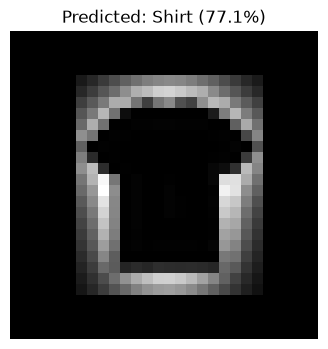

Predicted Fashion Item : Shirt
Confidence             : 77.14%


('Shirt', np.float32(0.7713807))

: 

In [ ]:
# Test Classifier Function (Load image, preprocess, and predict without retraining)
import os
from PIL import Image, ImageFilter
from scipy import ndimage

def prepare_image(pil_image):
    gray = pil_image.convert("L")
    a = np.asarray(gray, dtype=np.float32)
    big = max(gray.size)

    def ink(radius):
        bg = np.asarray(
            gray.filter(ImageFilter.GaussianBlur(radius)), dtype=np.float32
        )
        return np.clip(bg - a, 0, None)

    rough = ink(big / 12.0)
    if rough.max() == 0:
        return np.zeros((28, 28), np.float32)
    rough_mask = rough > 0.4 * rough.max()
    if not rough_mask.any():
        return np.zeros((28, 28), np.float32)
    stroke = 2.0 * np.percentile(
        ndimage.distance_transform_edt(rough_mask)[rough_mask], 90
    )
    a = ink(float(np.clip(3.0 * stroke, big / 60.0, big / 3.0)))

    if a.max() == 0:
        return np.zeros((28, 28), np.float32)

    mask = a > 0.35 * a.max()
    labels, n = ndimage.label(mask)
    if n > 1:
        sizes = ndimage.sum(mask, labels, range(1, n + 1))
        mask = labels == (1 + int(np.argmax(sizes)))
    if not mask.any():
        return np.zeros((28, 28), np.float32)

    ys, xs = np.where(mask)
    a = a[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]
    a = a / a.max() * 255.0

    h, w = a.shape
    scale = 20.0 / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    small = np.asarray(
        Image.fromarray(a.astype(np.uint8)).resize((nw, nh), Image.LANCZOS),
        dtype=np.float32,
    )

    out = np.zeros((28, 28), np.float32)
    top, left = (28 - nh) // 2, (28 - nw) // 2
    out[top : top + nh, left : left + nw] = small

    total = out.sum()
    if total > 0:
        idx = np.arange(28)
        dy = int(round(13.5 - out.sum(1) @ idx / total))
        dx = int(round(13.5 - out.sum(0) @ idx / total))
        shifted = np.zeros_like(out)
        y0, y1 = max(0, dy), 28 + min(0, dy)
        x0, x1 = max(0, dx), 28 + min(0, dx)
        shifted[y0:y1, x0:x1] = out[y0 - dy : y1 - dy, x0 - dx : x1 - dx]
        out = shifted

    return out / max(out.max(), 1e-6)

def test_fashion_image(image_filename, model=None):
    if model is None:
        model_path = 'Fashion_classification_1.keras'
        if not os.path.exists(model_path):
            model_path = 'Fashion_classification_cnn.keras'
        model = keras.models.load_model(model_path)
        
    img_path = image_filename
    if not os.path.exists(img_path) and os.path.exists(os.path.join('img', image_filename)):
        img_path = os.path.join('img', image_filename)
        
    pil_img = Image.open(img_path)
    img_array = prepare_image(pil_img)
    
    input_shape = model.input_shape
    if len(input_shape) == 4:
        X_input = img_array.reshape(1, 28, 28, 1)
    else:
        X_input = img_array.reshape(1, 28, 28)
        
    preds = model.predict(X_input, verbose=0)[0]
    pred_idx = preds.argmax()
    predicted_class = class_names[pred_idx]
    confidence = preds[pred_idx]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array, cmap='gray')
    plt.title(f'Predicted: {predicted_class} ({confidence:.1%})')
    plt.axis('off')
    plt.show()
    
    print(f"Predicted Fashion Item : {predicted_class}")
    print(f"Confidence             : {confidence:.2%}")
    return predicted_class, confidence

# Example execution (tests trouser.jpg without retraining)
test_fashion_image('pngtree-white-t-shirt-mockup-realistic-t-shirt-png-image_9906363.png')